# CEE6501 — Coding Assignment, Week 5

**Assigned:** 02/13/2026 (Week 5)  
**Due:** 02/23/2026

**Canvas Submission Link:**  <https://gatech.instructure.com/courses/517856/assignments/2320760>

---

## Logistics

### 💻 Assignment Format

This is a **coding assignment**.

- Complete the assignment by **executing and completing all tasks in the notebook cells below**
- The notebook should be run and completed in **Google Colab**
- Your submission **must be a link to a functioning Google Colab notebook**

You may use any local tools (VS Code, JupyterLab, etc.) while working, but the **final submitted work must run correctly in Colab**.


### 📤 Submission Instructions

- Submit **one link** to your Google Colab notebook on Canvas
- Ensure that:
  - All cells run **top-to-bottom without errors**
  - All required outputs are visible
  - The notebook reflects your final answers

### ✅ Checklist Before Submitting

- [ ] All notebook cells completed
- [ ] Code runs without errors from a fresh runtime
- [ ] Outputs and plots are clearly visible
- [ ] Colab link opens and runs correctly
- [ ] Correct notebook submitted on Canvas

### 🤝 Collaboration / AI tools
You may discuss concepts with classmates and you may use AI tools to help you learn,
but **your submitted code must be written by you and you must understand it**.
If you used outside help, add a short note in the final reflection cell.

---

## --- Google Colab environment setup ---

The cell below only needs to run when the notebook is opened in Google Colab.

This code will not affect code execution locally in VS-code + conda environment.

Google Colab starts each session with its own **preloaded versions** of common Python (currently 3.12.12) and Python packages (NumPy, SciPy, etc.).  
If we install different package versions once loaded, Python cannot switch to them while it is already running.

### What will happen
When you run the setup cell below in Google Colab:

1. The required package versions are installed
2. The runtime is **automatically restarted** so the new versions can be loaded  
3. You may see the message **“Your session crashed for an unknown reason.”**  
   → This is expected and normal

After the restart, rerun the notebook and check the **version check cell** to confirm package versions are correct.

### Runtime menu notes
- **Runtime → Restart session**  
  Restarts Python but keeps installed packages and saved files

- **Runtime → Disconnect and delete runtime**  
  Resets Colab completely to its default environment (packages will need to be reinstalled)

In [50]:
# ============================================================
# Google Colab environment setup (pinned versions)
# ============================================================

import sys
import os
import subprocess

if "google.colab" in sys.modules:
    print("Running in Google Colab")
    print("Python version:", sys.version.split()[0])

    # ---- Required package versions --------------------------
    requirements = {
        "numpy": "2.4.0",
        "scipy": "1.16.3",
        "matplotlib": "3.10.8",
        "pandas": "2.3.3",
        "plotly": "6.5.2"
    }

    # ---- Check currently loaded versions --------------------
    restart_needed = False

    for pkg, required_version in requirements.items():
        try:
            module = __import__(pkg)
            installed_version = module.__version__
        except Exception:
            installed_version = None

        print(f"{pkg}: {installed_version} (required: {required_version})")

        if installed_version != required_version:
            restart_needed = True

    # ---- Install if needed ----------------------------------
    if restart_needed:
        print("\nInstalling pinned package versions...")

        pip_args = [
            f"{pkg}=={ver}" for pkg, ver in requirements.items()
        ]

        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", *pip_args]
        )

        print("Installation complete.")
        print("Restarting runtime to load correct packages...")

        # This will appear as a "crash" in Colab — expected behavior
        os.kill(os.getpid(), 9)

    else:
        print("\nAll required package versions already installed.")

else:
    print("Not running in Google Colab — setup skipped.")
    print("Python version:", sys.version.split()[0])

Running in Google Colab
Python version: 3.12.12
numpy: 2.4.0 (required: 2.4.0)
scipy: 1.16.3 (required: 1.16.3)
matplotlib: 3.10.8 (required: 3.10.8)
pandas: 2.3.3 (required: 2.3.3)
plotly: 6.5.2 (required: 6.5.2)

All required package versions already installed.


In [51]:
# --- Version check ---
import numpy
import scipy
import matplotlib
import pandas
import plotly

print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:", pandas.__version__)
print("plotly:", plotly.__version__)

numpy: 2.4.0
scipy: 1.16.3
matplotlib: 3.10.8
pandas: 2.3.3
plotly: 6.5.2


---
---

## Imports

Run this cell once before starting the assignment.

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go

np.set_printoptions(precision=3, suppress=True)


---

## GIVEN CODE (You will need to modify):

## Parsing & Helper Functions

In [53]:
def restrained_dofs_1based(nodes_restrained, node_dofs_1based):
    """Return sorted list of restrained DOFs (1-based) from node restraints."""
    dof_restrained = []

    for node, restraints in nodes_restrained.items():
        ux_dof, uy_dof, uz_dof = node_dofs_1based(node)
        if "ux" in restraints:
            dof_restrained.append(ux_dof)
        if "uy" in restraints:
            dof_restrained.append(uy_dof)
        if "uz" in restraints:
            dof_restrained.append(uz_dof)

    return sorted(dof_restrained)

In [54]:
def loaded_dofs_1based(nodes_loaded, node_dofs_1based):
    """Return DOF→load mapping (1-based) from node loads."""
    dof_loaded = {}

    for node, (Fx, Fy, Fz) in nodes_loaded.items():
        ux_dof, uy_dof, uz_dof = node_dofs_1based(node)
        if Fx != 0.0:
            dof_loaded[ux_dof] = dof_loaded.get(ux_dof, 0.0) + Fx
        if Fy != 0.0:
            dof_loaded[uy_dof] = dof_loaded.get(uy_dof, 0.0) + Fy
        if Fz != 0.0:
            dof_loaded[uz_dof] = dof_loaded.get(uz_dof, 0.0) + Fz
    return dof_loaded


In [55]:
def node_dofs_1based(node_id):
    """Return engineering DOF numbers (1-based): [ux_dof, uy_dof]."""
    return [3* node_id - 2, 3 * node_id - 1, 3 * node_id]

## Element Level

In [56]:
def element_lmnL(xy_i, xy_j):
    xy_i = np.asarray(xy_i, dtype=float)
    xy_j = np.asarray(xy_j, dtype=float)

    dx = xy_j[0] - xy_i[0]
    dy = xy_j[1] - xy_i[1]
    dz = xy_j[2] - xy_i[2]
    L = float(np.sqrt(dx*dx + dy*dy + dz*dz))

    l = dx / L
    m = dy / L
    n=  dz / L

    return float(l), float(m), float(n), float(L)

In [57]:
def build_element_lmnL(element, nodes):
    """Return dict mapping element_id -> (l, m,n, L)."""
    elements_lmnL = {}

    for e_id, (i, j, E_e, A_e) in element.items():
        l, m,n, L = element_lmnL(nodes[i], nodes[j])
        elements_lmnL[e_id] = (l, m,n, L)

    return elements_lmnL

## Global Stiffness and Force

In [58]:
def initialize_global_stiffness(nodes):
    """Return zero-initialized global stiffness matrix."""
    ndof_total = 3 * len(nodes)
    return np.zeros((ndof_total, ndof_total), dtype=float)

In [59]:
def truss_element_kg(E, A, l,m,n, L):
    """Return 4x4 global stiffness matrix for a 2D truss element."""
    factor = (E * A) / L

    l2 = l * l
    m2 = m *m
    n2=n*n
    lm=l*m
    mn=m*n
    ln=n*l


    kg = factor * np.array(
        [
            [ l2, lm, ln, -l2, -lm, -ln],
            [ lm, m2, mn, -lm, -m2, -mn],
            [ ln, mn, n2, -ln, -mn, -n2],
            [-l2,-lm,-ln,  l2,  lm,  ln],
            [-lm,-m2,-mn,  lm,  m2,  mn],
            [-ln,-mn,-n2,  ln,  mn,  n2],
        ],
        dtype=float,
    )
    return kg

In [60]:
def element_dof_map_1based(i_node, j_node):
    """Return the 6 global DOF indices (1-based) for element (i, j).

    Order matches the 4x4 element stiffness matrix:
    [u_ix, u_iy, u_iz, u_jx, u_jy, u_jz]
    """
    # Engineering DOF numbers (1-based)
    dofs_i_1 = [3 * i_node - 2, 3 * i_node-1, 3 * i_node]
    dofs_j_1 = [3 * j_node - 2, 3 * j_node-1, 3 * j_node]
    dofs_1based = dofs_i_1 + dofs_j_1
    return dofs_1based

In [61]:
def assemble_global_stiffness(element, nodes, element_lmnL, print_toggle):
    """Assemble and return the global stiffness matrix K (dense) for a 3D truss."""

    K = initialize_global_stiffness(nodes)

    for e_id, (i, j, E_e, A_e) in element.items():
        l,m,n, L = element_lmnL[e_id]
        ke = truss_element_kg(E_e, A_e, l,m,n, L)

        dof_map = element_dof_map_1based(i, j)

        # Scatter-add ke into K. Must be 0-based indexing, hence -1
        for a in range(6):
            A = dof_map[a] - 1
            for b in range(6):
                B = dof_map[b] - 1
                K[A, B] += ke[a, b]

        # Optional: show progress while learning/debugging
        if print_toggle:
            print_matrix_scaled(ke)
            print(f"Assembled element {e_id}: nodes ({i},{j}) -> DOFs {dof_map}")
            print_matrix_scaled(K)
            print("-" * 70)

    return K

In [62]:
def assemble_global_force_vector(nodes, dof_loaded_1based):
    """Return global force vector assembled from 1-based DOF loads."""
    ndof_total = 3 * len(nodes)
    f_global = np.zeros(ndof_total, dtype=float)

    for dof_1based, value in dof_loaded_1based.items():
        f_global[dof_1based - 1] = value  # convert to 0-based index

    return f_global

## Partition

In [63]:
def partition_system(K, f, dof_restrained_1based):
    ndof = K.shape[0]

    # Convert restrained DOFs to 0-based
    restrained_dofs = sorted(d - 1 for d in dof_restrained_1based)

    # Free DOFs
    free_dofs = [i for i in range(ndof) if i not in restrained_dofs]

    # Partition stiffness matrix
    K_ff = K[np.ix_(free_dofs, free_dofs)]
    K_fr = K[np.ix_(free_dofs, restrained_dofs)]
    K_rf = K[np.ix_(restrained_dofs, free_dofs)]
    K_rr = K[np.ix_(restrained_dofs, restrained_dofs)]

    # Partition force vector
    f_f = f[free_dofs]
    f_r = f[restrained_dofs]

    return K_ff, K_fr, K_rf, K_rr, f_f, f_r, free_dofs, restrained_dofs


## Solve Displacements

In [64]:
def solve_free_displacements(K_ff, K_fr, f_f, u_r=None):
    if u_r is None:
        u_r = np.zeros(K_fr.shape[1])

    rhs = f_f - K_fr @ u_r
    u_f = np.linalg.solve(K_ff, rhs)

    return u_f


## Solve Support Forces

In [65]:
def solve_support_forces(K_rf, K_rr, u_f, u_r=None):
    if u_r is None:
        u_r = np.zeros(K_rr.shape[0])

    F_r = K_rf @ u_f + K_rr @ u_r
    return F_r


## Backward Pass

In [66]:
def assemble_global_displacements(u_f, free_dofs, restrained_dofs, u_r=None):
    """
    Assemble the full global displacement vector u from partitioned results.
    """
    ndof_total = len(free_dofs) + len(restrained_dofs)
    u_global = np.zeros(ndof_total)

    if u_r is None:
        u_r = np.zeros(len(restrained_dofs))

    u_global[free_dofs] = u_f
    u_global[restrained_dofs] = u_r

    return u_global


In [67]:
def assemble_global_forces(f_f, F_r, free_dofs, restrained_dofs):
    """
    Assemble the full global force vector f from applied loads and reactions.
    """
    ndof_total = len(free_dofs) + len(restrained_dofs)
    f_global = np.zeros(ndof_total)

    f_global[free_dofs] = f_f
    f_global[restrained_dofs] = F_r

    return f_global


In [68]:
def extract_element_displacements(u_global, i_node, j_node):
    """
    Extract the 4x1 element global displacement vector u_e.
    Order: [u_ix, u_iy,u_iz, u_jx, u_jy, u_jz]
    """
    dofs_1based = [3 * i_node - 2, 3 * i_node-1,  3 * i_node,
                   3 * j_node - 2, 3 * j_node-1,  3 * j_node, ]
    idx = [d - 1 for d in dofs_1based]  # convert to 0-based
    return u_global[idx]

In [69]:
def truss_transformation_matrix(l,m,n):
    ex_p = np.array([l, m, n], dtype=float)
    if abs(n) < 0.9:
        a = np.array([0.0, 0.0, 1.0])
    else:
        a = np.array([0.0, 1.0, 0.0])
    ey_n=np.cross(a,ex_p)
    ey_d=np.linalg.norm(ey_n)
    ey_p=ey_n/ey_d
    ez_p=np.cross(ex_p,ey_p)
    R=np.vstack((ex_p,ey_p,ez_p))
    I= np.zeros((3, 3), dtype=float)
    T = np.block([[R, I],
                  [I, R]])
    return T


def compute_local_displacements(l,m,n, u_e):
    T = truss_transformation_matrix(l,m,n)
    return T @ u_e



In [70]:
def truss_local_stiffness(E, A, L):
    k = (E * A / L) * np.array(
        [
            [ 1, 0, 0, -1, 0, 0],
            [ 0, 0, 0,  0, 0, 0],
            [ 0, 0, 0,  0, 0, 0],
            [-1, 0, 0,  1, 0, 0],
            [ 0, 0, 0,  0, 0, 0],
            [ 0, 0, 0,  0, 0, 0],
        ],
        dtype=float,
    )
    return k

In [71]:
def compute_local_end_forces(E, A, L, u_local):
    k_local = truss_local_stiffness(E, A, L)
    return k_local @ u_local

In [72]:
def compute_axial_force_and_stress(E, A, L, u_local):
    # axial displacements are the local DOFs along the member axis
    u_i_axial = u_local[0]
    u_j_axial = u_local[3]

    N = (E * A / L) * (u_j_axial - u_i_axial)
    sigma = N / A
    return N, sigma

In [73]:
def local_to_global_forces(l,m,n, f_local):
    T = truss_transformation_matrix(l,m,n)
    return T.T @ f_local

## Post-Processing & Output

In [74]:
def plot_truss_deformation(nodes, element, u_global, scale=1.0):
    """
    Plot original (black) and deformed (red) truss geometry.
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    for e_id, (i, j, *_ ) in element.items():
        xi, yi ,zi= nodes[i]
        xj, yj, zj = nodes[j]

        ui = u_global[3*(i-1):3*(i-1)+3]
        uj = u_global[3*(j-1):3*(j-1)+3]
        # original
        ax.plot([xi, xj], [yi, yj], [zi, zj], "k-", lw=2)

        # deformed
        ax.plot(
            [xi + scale*ui[0], xj + scale*uj[0]],
            [yi + scale*ui[1], yj + scale*uj[1]],
            [zi + scale*ui[2], zj + scale*uj[2]],
            "r-", lw=2
        )


    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(f"Original (black) and deformed (red), scale={scale}")
    plt.show()


In [75]:
def recover_element_results(elements, elements_lmnL, u_global):
    results = {}

    for e_id, (i, j, E_e, A_e) in elements.items():
        l, m, n, L = elements_lmnL[e_id]

        u_e = extract_element_displacements(u_global, i, j)
        u_local = compute_local_displacements(l, m, n, u_e)
        f_local = compute_local_end_forces(E_e, A_e, L, u_local)
        N, sigma = compute_axial_force_and_stress(E_e, A_e, L, u_local)

        results[e_id] = {
            "u_e": u_e,
            "u_local": u_local,
            "f_local": f_local,
            "N": N,          # kN
            "sigma": sigma,  # GPa
        }

    return results

In [76]:
def build_element_results_dataframe(element, elements_lmnL, results):
    """Return pandas DataFrame of element-level results."""
    rows = []

    for e_id in sorted(element.keys()):
        i, j, _, _ = element[e_id]
        _, _,_, L = elements_lmnL[e_id]
        r = results[e_id]

        row = {
            "ele": e_id,
            "i": i,
            "j": j,
            "L (mm)": round(L, 1),
            "N (kN)": round(r["N"], 1),
            "sigma (MPa)": round(r["sigma"] * 1000, 1),
        }

        # global displacements u_e
        row.update({f"u_{k+1} (mm)": round(r["u_e"][k], 1) for k in range(6)})
        # local displacements u'
        row.update({f"u_{k+1}' (mm)": round(r["u_local"][k], 1) for k in range(6)})
        # local end forces f'
        row.update({f"f_{k+1}' (kN)": round(r["f_local"][k], 1) for k in range(6)})

        rows.append(row)

    return pd.DataFrame(rows)


In [77]:
def display_compact(df):
    return (
        df.style
        .format({
            col: "{:.1f}"
            for col in df.columns
            if any(key in col for key in ["(mm)", "(kN)", "(MPa)", "L"])
        })
        .set_properties(**{
            "font-size": "9pt",
            "padding": "2px",
            "white-space": "nowrap",
        })
        .set_table_styles([
            {"selector": "th", "props": [("font-size", "9pt")]},
        ])
    )

In [78]:
def print_matrix_scaled(K, scale=1, decimals=2, col_width=7):
    """
    Print K/scale row-by-row, compact, with DOF labels.
    """
    fmt = f"{{:{col_width}.{decimals}f}}"
    print(f"K = {scale:.0e} ×")
    for i, row in enumerate(K, start=1):
        row_scaled = row / scale
        row_str = " ".join(fmt.format(val) for val in row_scaled)
        print(f"{i:2d} | {row_str}")

---
---

## Question 3 — Extending the Truss Analysis Code to 3D (20 points)

Extend the functions defined at the beginning of this workbook so that they operate in **three dimensions**. This requires:

- Updating the number of degrees of freedom per node from **2 → 3**
- Modifying all related indexing, assembly, and bookkeeping to be consistent with 3D kinematics
- Use the 3D local/global truss element formulation presented in class
- Applying an appropriate set of **support restraints** for a 3D truss system (including out-of-plane constraints)

Verify that the **statically determinate truss** analyzed in the written assignment produces **consistent and correct results** when solved using your 3D computational implementation. You should get the same answer across 2D and 3D implementation if you are doing things correctly.

### Implementation Guidance

As an example, in the function below, extending the formulation to 3D requires changing the total number of degrees of freedom from `2 * len(nodes)` to `3 * len(nodes)`. Similar changes will be required throughout your code so that it correctly assembles, solves, and visualizes a **3D structure**. Use a **3D axis** when plotting with `matplotlib`, or an even better option is to use `plotly` to plot dynamic 3D plots.

```python
def assemble_global_force_vector(nodes, dof_loaded_1based):
    """Return global force vector assembled from 1-based DOF loads."""
    ndof_total = 2 * len(nodes)
    f_global = np.zeros(ndof_total, dtype=float)

    for dof_1based, value in dof_loaded_1based.items():
        f_global[dof_1based - 1] = value  # convert to 0-based index

    return f_global


### Q3.1. Problem Setup
Define all model inputs (nodes, elements, supports, loads) using the same data structures and conventions as we did in lecture but extended to 3D.

Present:
- Node coordinates
- Element connectivity and properties
- Applied loads and boundary conditions

In [79]:
# -------------------------
# Nodes: (x,y,z)
# -------------------------
nodes = {
    1: (0.0, 0.0, 0.0),
    2: (1000.0, 1000.0, 0.0),
    3: (2000.0, 2000.00, 0.0),
    4: (3000.0, 1000.0, 0.0),
    5: (4000.0, 0.0, 0.0),
    6: (2000.0, 0.0, 0.0)
}
# Quick check: DOFs for each node
{nid: node_dofs_1based(nid) for nid in nodes}


{1: [1, 2, 3],
 2: [4, 5, 6],
 3: [7, 8, 9],
 4: [10, 11, 12],
 5: [13, 14, 15],
 6: [16, 17, 18]}

In [80]:
E = 70.0   # GPa
A = 4000.0    # mm^2

# -------------------------
# Elements: (i, j, E, A)
# -------------------------
elements = {
    1: (1, 2, E, A),
    2: (2, 3, E, A),
    3: (3, 4, E, A),
    4: (4, 5, E, A),
    5: (2, 6, E, A),
    6: (4, 6, E, A),
    7: (3, 6, E, A),
    8: (1, 6, E, A),
    9: (6, 5, E, A),
}

elements_csl = build_element_lmnL(elements, nodes)


In [81]:
# -------------------------
# Supports / restraints
# -------------------------
nodes_restrained =  {
    1: ["ux", "uy", "uz"],   # pin
    5: ["uy", "uz"],   # roller
    2: ["uz"],
    3: ["uz"],
    4: ["uz"],
    6: ["uz"],
}

# -------------------------
# Applied nodal loads (Fx, Fy, Fz)
# -------------------------
nodes_loaded = {
    2: (0.0, -2.0, 0.0),
    4: (1, 0.0, 0.0)
}

dof_restrained_1based = restrained_dofs_1based(nodes_restrained, node_dofs_1based)
dof_loaded_1based = loaded_dofs_1based(nodes_loaded, node_dofs_1based)


### Q3.2 Analysis

Solve the truss using the space truss functions you need to develop (edit the code at the start of this workbook).

Report key numerical results, such as:
- Support reactions
- Member axial forces
- Maximum nodal displacements
- Present summary tables
- Plot displaced shape at a reasonable scale

In [82]:
print_toggle = 0
elements_lmnL = build_element_lmnL(elements, nodes)
K_global = assemble_global_stiffness(elements, nodes, elements_lmnL, print_toggle)

f_global = assemble_global_force_vector(nodes, dof_loaded_1based)

(
    K_ff,
    K_fr,
    K_rf,
    K_rr,
    f_f,
    f_r,
    free_dofs,
    restrained_dofs,
) = partition_system(K_global, f_global, dof_restrained_1based)

u_f = solve_free_displacements(K_ff, K_fr, f_f)
F_r = solve_support_forces(K_rf, K_rr, u_f)
u_global = assemble_global_displacements(u_f, free_dofs, restrained_dofs)
f_global_complete = assemble_global_forces(f_f, F_r, free_dofs, restrained_dofs)


In [83]:
print("Support reactions by node:")
for node in sorted(nodes_restrained.keys()):
    Rx = 0.0
    Ry = 0.0
    Rz=0.0

    if "ux" in nodes_restrained[node]:
        dof0 = 3*node - 3
        Rx = float(F_r[list(restrained_dofs).index(dof0)])
    if "uy" in nodes_restrained[node]:
        dof0 = 3*node - 2
        Ry = float(F_r[list(restrained_dofs).index(dof0)])
    if "uz" in nodes_restrained[node]:
        dof0 = 3*node - 1
        Rz = float(F_r[list(restrained_dofs).index(dof0)])

    print(f"Node {node}: Rx = {Rx:.6g} kN, Ry = {Ry:.6g} kN, Rz = {Rz:.6g} kN")


Support reactions by node:
Node 1: Rx = -1 kN, Ry = 1.25 kN, Rz = 0 kN
Node 2: Rx = 0 kN, Ry = 0 kN, Rz = 0 kN
Node 3: Rx = 0 kN, Ry = 0 kN, Rz = 0 kN
Node 4: Rx = 0 kN, Ry = 0 kN, Rz = 0 kN
Node 5: Rx = 0 kN, Ry = 0.75 kN, Rz = 0 kN
Node 6: Rx = 0 kN, Ry = 0 kN, Rz = 0 kN


In [84]:
# Plotting function for 3D trusses (Plotly version).
# This mirrors the Matplotlib, but works interactively everywhere (Jupyter, Colab, VS Code, etc.).

def plot_truss_3d_plotly(
    nodes,
    element,
    nodes_restrained=None,
    nodes_loaded=None,
    show_node_ids=True,
    show_member_ids=False,
    load_scale=0.02,
):
    """
    nodes: {nid: (x,y,z)}
    element: {eid: (i,j,E,A)}
    nodes_restrained: {nid: ["ux","uy","uz"], ...}
    nodes_loaded: {nid: (Fx,Fy,Fz)}
    """

    # ---- normalize nodes to 3D ----
    nodes3 = {}
    for nid, xyz in nodes.items():
        if len(xyz) == 2:
            x, y = xyz
            z = 0.0
        else:
            x, y, z = xyz
        nodes3[nid] = (float(x), float(y), float(z))

    fig = go.Figure()

    # =========================================================
    # Members (lines)
    # =========================================================
    xs, ys, zs = [], [], []
    for eid, (i, j, E, A) in element.items():
        xi, yi, zi = nodes3[i]
        xj, yj, zj = nodes3[j]
        xs += [xi, xj, None]
        ys += [yi, yj, None]
        zs += [zi, zj, None]

    fig.add_trace(
        go.Scatter3d(
            x=xs,
            y=ys,
            z=zs,
            mode="lines",
            line=dict(width=3),
            name="Members",
        )
    )

    # Optional member IDs (text at midpoints)
    if show_member_ids:
        mx, my, mz, mt = [], [], [], []
        for eid, (i, j, E, A) in element.items():
            xi, yi, zi = nodes3[i]
            xj, yj, zj = nodes3[j]
            mx.append((xi + xj) / 2)
            my.append((yi + yj) / 2)
            mz.append((zi + zj) / 2)
            mt.append(str(eid))

        fig.add_trace(
            go.Scatter3d(
                x=mx,
                y=my,
                z=mz,
                mode="text",
                text=mt,
                name="Member IDs",
            )
        )

    # =========================================================
    # Nodes
    # =========================================================
    nx = [p[0] for p in nodes3.values()]
    ny = [p[1] for p in nodes3.values()]
    nz = [p[2] for p in nodes3.values()]

    fig.add_trace(
        go.Scatter3d(
            x=nx,
            y=ny,
            z=nz,
            mode="markers",
            marker=dict(size=4),
            name="Nodes",
        )
    )

    if show_node_ids:
        fig.add_trace(
            go.Scatter3d(
                x=nx,
                y=ny,
                z=nz,
                mode="text",
                text=[str(nid) for nid in nodes3.keys()],
                textposition="top center",
                name="Node IDs",
            )
        )

    # =========================================================
    # Supports
    # =========================================================
    if nodes_restrained:
        sx, sy, sz = [], [], []
        for nid in nodes_restrained.keys():
            x, y, z = nodes3[nid]
            sx.append(x)
            sy.append(y)
            sz.append(z)

        fig.add_trace(
            go.Scatter3d(
                x=sx,
                y=sy,
                z=sz,
                mode="markers",
                marker=dict(size=7),
                name="Supports",
            )
        )

    # =========================================================
    # Loads (true arrows using cones)
    # =========================================================
    if nodes_loaded:
        lx, ly, lz = [], [], []
        u, v, w = [], [], []

        for nid, (Fx, Fy, Fz) in nodes_loaded.items():
            x, y, z = nodes3[nid]
            lx.append(x)
            ly.append(y)
            lz.append(z)

            # direction + magnitude
            u.append(load_scale * Fx)
            v.append(load_scale * Fy)
            w.append(load_scale * Fz)

        fig.add_trace(
            go.Cone(
                x=lx,
                y=ly,
                z=lz,
                u=u,
                v=v,
                w=w,
                anchor="tail",   # arrow starts at node
                sizemode="absolute",
                sizeref=0.2,     # adjust arrowhead size
                showscale=False,
                name="Loads",
            )
        )


    # =========================================================
    # Layout (mirrors Matplotlib intent)
    # =========================================================
    fig.update_layout(
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z",
            aspectmode="data",  # equal-ish aspect
            camera=dict(
                eye=dict(x=1.4, y=1.4, z=0.9)  # similar to elev=20, azim=30
            ),
        ),
        margin=dict(l=0, r=0, t=30, b=0),
        title="3D Truss",
        showlegend=True,
    )

    fig.show()


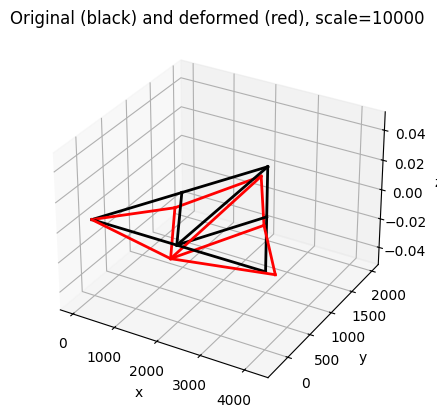

In [85]:
plot_truss_deformation(nodes, elements, u_global, scale=10000)

In [86]:
plot_truss_3d_plotly(
    nodes,
    elements,
    nodes_restrained,
    nodes_loaded,
    show_node_ids=True,
    show_member_ids=False,
    load_scale=0.5,
)

In [87]:
results = recover_element_results(elements, elements_lmnL, u_global)
df_members = build_element_results_dataframe(elements, elements_lmnL, results)

display_compact(df_members)

,ele,i,j,L (mm),N (kN),sigma (MPa),u_1 (mm),u_2 (mm),u_3 (mm),u_4 (mm),u_5 (mm),u_6 (mm),u_1' (mm),u_2' (mm),u_3' (mm),u_4' (mm),u_5' (mm),u_6' (mm),f_1' (kN),f_2' (kN),f_3' (kN),f_4' (kN),f_5' (kN),f_6' (kN)
0,1,1,2,1414.2,-1.8,-0.4,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,1.8,0.0,0.0,-1.8,0.0,0.0
1,2,2,3,1414.2,-0.4,-0.1,0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,0.4,0.0,0.0,-0.4,0.0,0.0
2,3,3,4,1414.2,-0.4,-0.1,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,0.4,0.0,0.0,-0.4,0.0,0.0
3,4,4,5,1414.2,-1.1,-0.3,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,1.1,0.0,0.0,-1.1,0.0,0.0
4,5,2,6,1414.2,-1.4,-0.4,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,1.4,0.0,0.0,-1.4,0.0,0.0
5,6,4,6,1414.2,0.7,0.2,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.7,0.0,0.0,0.7,0.0,0.0
6,7,3,6,2000.0,0.5,0.1,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.5,0.0,0.0,0.5,0.0,0.0
7,8,1,6,2000.0,2.3,0.6,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,-2.3,0.0,0.0,2.3,0.0,0.0
8,9,6,5,2000.0,0.8,0.2,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,-0.8,0.0,0.0,0.8,0.0,0.0


In [88]:
# Choose one element to sanity-check
e_test = 1

# --- Geometry + properties ---
i, j, E, A = elements[e_test]
l, m, n, L = elements_lmnL[e_test]


print(f"Element {e_test}: nodes ({i}, {j})")
print(f"l = {l:.6f}, m = {m:.6f}, n = {n:.6f},L = {L:.3f} mm")

# --- Displacements ---
u_e = extract_element_displacements(u_global, i, j)
print(f"u_e (ele {e_test} global displacements) = {u_e}")

u_local = compute_local_displacements(l,m,n, u_e)
print(f"u_local (ele {e_test} local displacements) = {u_local}")

# --- Forces / stress ---
f_local = compute_local_end_forces(E, A, L, u_local)
print(f"f_local (ele {e_test} local end forces) = {f_local}")

N, sigma = compute_axial_force_and_stress(E, A, L, u_local)
print(f"Axial force  N = {N:.3f} kN")
print(f"Axial stress σ = {sigma:.6f} GPa  ({sigma*1000:.2f} MPa)")

f_global_e = local_to_global_forces(l,m,n, f_local)
print(f"f_global_e (ele {e_test} end forces in global coords) = {f_global_e}")


Element 1: nodes (1, 2)
l = 0.707107, m = 0.707107, n = 0.000000,L = 1414.214 mm
u_e (ele 1 global displacements) = [ 0.     0.     0.     0.02  -0.033  0.   ]
u_local (ele 1 local displacements) = [ 0.     0.     0.    -0.009 -0.038  0.   ]
f_local (ele 1 local end forces) = [ 1.768  0.     0.    -1.768  0.     0.   ]
Axial force  N = -1.768 kN
Axial stress σ = -0.000442 GPa  (-0.44 MPa)
f_global_e (ele 1 end forces in global coords) = [ 1.25  1.25  0.   -1.25 -1.25  0.  ]


### YOUR ANSWER FOR Q3.2 IN THIS CELL:

Use as many cells as you need
##Support reactions by node:
Node 1: Rx = -1 kN, Ry = 1.25 kN, Rz = 0 kN\
Node 2: Rx = 0 kN, Ry = 0 kN, Rz = 0 kN\
Node 3: Rx = 0 kN, Ry = 0 kN, Rz = 0 kN\
Node 4: Rx = 0 kN, Ry = 0 kN, Rz = 0 kN\
Node 5: Rx = 0 kN, Ry = 0.75 kN, Rz = 0 kN\
Node 6: Rx = 0 kN, Ry = 0 kN, Rz = 0 kN
##Member axial forces
- Element 1 (1–2): N = −1.8 kN  
- Element 2 (2–3): N = −0.4 kN  
- Element 3 (3–4): N = −0.4 kN  
- Element 4 (4–5): N = −1.1 kN  
- Element 5 (2–6): N = −1.4 kN  
- Element 6 (4–6): N = +0.7 kN  
- Element 7 (3–6): N = +0.5 kN  
- Element 8 (1–6): N = +2.3 kN  
- Element 9 (6–5): N = +0.8 kN  
  
##Maximum nodal displacements
Since the load is very small, the displacemens are not seen in the table due to rounding. I checked by increasing the load to hundred times and it gave displacements. But did not keep it as the hand written submission contains the lesser load that shows o displacements.
##Present summary tables
(See previous cell)
##Plot displaced shape at a reasonable scale
(See previous cell)

---

### Q3.3 Discussion

Compare the support reactions and member foces obtained from your code with those calculated by hand and with the 2D analysis performed in Q1. State whether they agree, and briefly summarize your findings in the final cell using **Markdown** and **LaTeX** as appropriate.

### YOUR ANSWER FOR Q1.3 IN THIS CELL:

Use as many cells as you need\
## Results (from hand)

### Support reactions (kN)
- \(R_{1x} = -1.00\)
- \(R_{1y} = +1.25\)
- \(R_{2y} = +0.75\)

### Member axial forces (kN)
- \(R_1 = 1.77\) (C)
- \(R_2 = 0.36\) (C)
- \(R_3 = 0.35\) (C)
- \(R_4 = 1.06\) (C)
- \(R_5 = 1.42\) (C)
- \(R_6 = 0.707\) (T)
- \(R_7 = 0.50\) (T)
- \(R_8 = 2.25\) (T)
- \(R_9 = 0.75\) (T)

C = compression, T = tension\
They agree, if rounded to one decimal place.

---
---

## Question 4 — Case Study Space Truss Analysis (30 points)

Analyze the following space truss given your 3D code that you have verified gives correct answers from Q3.

Pin-jointed **3D space truss** with **translational DOFs only** at each node:
$$(U_x, U_y, U_z)$$

Information given in units
- Length: m
- Force: kN

### Model Summary

| Quantity | Value |
|--------:|------:|
| Nodes | 18 |
| Members | 53 |
| Total DOFs | $18 \times 3 = 54$ |
| Restrained DOFs | 6 |
| Free DOFs | 48 |
| Structural Type | 3D space truss |
| Load Case | Vertical + lateral |

$ E = 200 $ GPa

>Careful of units, make sure to convert to same basis


### Nodes

Bottom Layer ($z = 0$)

| Node | $x$ | $y$ | $z$ |
|-----:|----:|----:|----:|
| 1 | 0 | 0 | 0 |
| 2 | 1 | 0 | 0 |
| 3 | 2 | 0 | 0 |
| 4 | 0 | 1 | 0 |
| 5 | 1 | 1 | 0 |
| 6 | 2 | 1 | 0 |
| 7 | 0 | 2 | 0 |
| 8 | 1 | 2 | 0 |
| 9 | 2 | 2 | 0 |

Top Layer ($z = 1.2$)

| Node | $x$ | $y$ | $z$ |
|-----:|----:|----:|----:|
| 10 | 0 | 0 | 1.2 |
| 11 | 1 | 0 | 1.2 |
| 12 | 2 | 0 | 1.2 |
| 13 | 0 | 1 | 1.2 |
| 14 | 1 | 1 | 1.2 |
| 15 | 2 | 1 | 1.2 |
| 16 | 0 | 2 | 1.2 |
| 17 | 1 | 2 | 1.2 |
| 18 | 2 | 2 | 1.2 |


### Members (Connectivity)

Bottom Chord – Edges

| Member | $i$ | $j$ | $A$ ($mm^2$) |
|-------:|----:|----:|-------------:|
| 1 | 1 | 2 | 1200 |
| 2 | 2 | 3 | 1200 |
| 3 | 4 | 5 | 1200 |
| 4 | 5 | 6 | 1200 |
| 5 | 7 | 8 | 1200 |
| 6 | 8 | 9 | 1200 |
| 7 | 1 | 4 | 1200 |
| 8 | 4 | 7 | 1200 |
| 9 | 2 | 5 | 1200 |
| 10 | 5 | 8 | 1200 |
| 11 | 3 | 6 | 1200 |
| 12 | 6 | 9 | 1200 |

Bottom Chord – Diagonals

| Member | $i$ | $j$ | $A$ ($mm^2$) |
|-------:|----:|----:|-------------:|
| 13 | 1 | 5 | 900 |
| 14 | 2 | 6 | 900 |
| 15 | 4 | 8 | 900 |
| 16 | 5 | 9 | 900 |

Top Chord – Edges


| Member | $i$ | $j$ | $A$ ($mm^2$) |
|-------:|----:|----:|-------------:|
| 17 | 10 | 11 | 900 |
| 18 | 11 | 12 | 900 |
| 19 | 13 | 14 | 900 |
| 20 | 14 | 15 | 900 |
| 21 | 16 | 17 | 900 |
| 22 | 17 | 18 | 900 |
| 23 | 10 | 13 | 900 |
| 24 | 13 | 16 | 900 |
| 25 | 11 | 14 | 900 |
| 26 | 14 | 17 | 900 |
| 27 | 12 | 15 | 900 |
| 28 | 15 | 18 | 900 |

Top Chord – Diagonals

| Member | $i$ | $j$ | $A$ ($mm^2$) |
|-------:|----:|----:|-------------:|
| 29 | 10 | 14 | 700 |
| 30 | 11 | 15 | 700 |
| 31 | 13 | 17 | 700 |
| 32 | 14 | 18 | 700 |

Web Members - Verticals

| Member | $i$ | $j$ | $A$ ($mm^2$) |
|-------:|----:|----:|-------------:|
| 33 | 1 | 10 | 700 |
| 34 | 2 | 11 | 700 |
| 35 | 3 | 12 | 700 |
| 36 | 4 | 13 | 700 |
| 37 | 5 | 14 | 700 |
| 38 | 6 | 15 | 700 |
| 39 | 7 | 16 | 700 |
| 40 | 8 | 17 | 700 |
| 41 | 9 | 18 | 700 |


Web Members - Cross-Layer Diagonals

| Member | $i$ | $j$ | $A$ ($mm^2$) |
|-------:|----:|----:|-------------:|
| 42 | 10 | 2 | 600 |
| 43 | 11 | 3 | 600 |
| 44 | 13 | 5 | 600 |
| 45 | 14 | 6 | 600 |
| 46 | 16 | 8 | 600 |
| 47 | 17 | 9 | 600 |
| 48 | 10 | 4 | 600 |
| 49 | 13 | 7 | 600 |
| 50 | 11 | 5 | 600 |
| 51 | 14 | 8 | 600 |
| 52 | 12 | 6 | 600 |
| 53 | 15 | 9 | 600 |



### Supports / Fixities

Translational restraints only for truss.

| Node | $U_x$ | $U_y$ | $U_z$ |
|-----:|:----:|:----:|:----:|
| 1 | fixed | fixed | fixed |
| 3 | free | fixed | fixed |
| 7 | free | free | fixed |

Total restrained DOFs: $3 + 2 + 1 = 6$

### Applied Loads

Nodal Loads (kN)

| Node | $F_x$ | $F_y$ | $F_z$ |
|-----:|-----:|-----:|-----:|
| 10 | $+10$ | $+10$ | $-10$ |
| 11 | $+10$ | $+10$ | $-10$ |
| 12 | $+10$ | $+10$ | $-10$ |
| 13 | $+5$ | $0$ | $-10$ |
| 14 | $+5$ | $0$ | $-50$ |
| 15 | $+5$ | $0$ | $-10$ |
| 16 | $+5$ | $0$ | $-10$ |
| 17 | $+5$ | $0$ | $-10$ |
| 18 | $+5$ | $0$ | $-10$ |

All other nodes: $F_x = F_y = F_z = 0$


---

### Q4.1. Problem Setup
Define all model inputs (nodes, elements, supports, loads) using the same data structures and conventions as in **Question 3**.

Present:
- Node coordinates
- Element connectivity and properties
- Applied loads and boundary conditions

In [89]:
# -------------------------
# Nodes: (x,y,z)
# -------------------------
nodes = {
    # bottom layer z=0
    1: (0,    0,    0),
    2: (1000, 0,    0),
    3: (2000, 0,    0),
    4: (0,    1000, 0),
    5: (1000, 1000, 0),
    6: (2000, 1000, 0),
    7: (0,    2000, 0),
    8: (1000, 2000, 0),
    9: (2000, 2000, 0),
    # top layer z=1200
    10: (0,    0,    1200),
    11: (1000, 0,    1200),
    12: (2000, 0,    1200),
    13: (0,    1000, 1200),
    14: (1000, 1000, 1200),
    15: (2000, 1000, 1200),
    16: (0,    2000, 1200),
    17: (1000, 2000, 1200),
    18: (2000, 2000, 1200),
}
# Quick check: DOFs for each node
{nid: node_dofs_1based(nid) for nid in nodes}

{1: [1, 2, 3],
 2: [4, 5, 6],
 3: [7, 8, 9],
 4: [10, 11, 12],
 5: [13, 14, 15],
 6: [16, 17, 18],
 7: [19, 20, 21],
 8: [22, 23, 24],
 9: [25, 26, 27],
 10: [28, 29, 30],
 11: [31, 32, 33],
 12: [34, 35, 36],
 13: [37, 38, 39],
 14: [40, 41, 42],
 15: [43, 44, 45],
 16: [46, 47, 48],
 17: [49, 50, 51],
 18: [52, 53, 54]}

In [90]:
E = 200
A1 = 1200.0  # bottom edges
A2 = 900.0   # bottom diagonals + top edges
A3 = 700.0   # top diagonals + verticals
A4 = 600.0   # cross-layer diagonals

# -------------------------
# Elements: (i, j, E, A)
# -------------------------
element = {
    # Bottom chord – edges (A1)
    1: (1, 2, E, A1),
    2: (2, 3, E, A1),
    3: (4, 5, E, A1),
    4: (5, 6, E, A1),
    5: (7, 8, E, A1),
    6: (8, 9, E, A1),
    7: (1, 4, E, A1),
    8: (4, 7, E, A1),
    9: (2, 5, E, A1),
    10: (5, 8, E, A1),
    11: (3, 6, E, A1),
    12: (6, 9, E, A1),

    # Bottom chord – diagonals (A2)
    13: (1, 5, E, A2),
    14: (2, 6, E, A2),
    15: (4, 8, E, A2),
    16: (5, 9, E, A2),

    # Top chord – edges (A2)
    17: (10, 11, E, A2),
    18: (11, 12, E, A2),
    19: (13, 14, E, A2),
    20: (14, 15, E, A2),
    21: (16, 17, E, A2),
    22: (17, 18, E, A2),
    23: (10, 13, E, A2),
    24: (13, 16, E, A2),
    25: (11, 14, E, A2),
    26: (14, 17, E, A2),
    27: (12, 15, E, A2),
    28: (15, 18, E, A2),
    29: (10, 14, E, A3),
    30: (11, 15, E, A3),
    31: (13, 17, E, A3),
    32: (14, 18, E, A3),

    # Web members – verticals (A3)
    33: (1, 10, E, A3),
    34: (2, 11, E, A3),
    35: (3, 12, E, A3),
    36: (4, 13, E, A3),
    37: (5, 14, E, A3),
    38: (6, 15, E, A3),
    39: (7, 16, E, A3),
    40: (8, 17, E, A3),
    41: (9, 18, E, A3),

    # Web members – cross-layer diagonals (A4)
    42: (10, 2, E, A4),
    43: (11, 3, E, A4),
    44: (13, 5, E, A4),
    45: (14, 6, E, A4),
    46: (16, 8, E, A4),
    47: (17, 9, E, A4),
    48: (10, 4, E, A4),
    49: (13, 7, E, A4),
    50: (11, 5, E, A4),
    51: (14, 8, E, A4),
    52: (12, 6, E, A4),
    53: (15, 9, E, A4),
}


In [91]:
# -------------------------
# Supports / restraints
# -------------------------
nodes_restrained = {
    1: ["ux", "uy", "uz"],
    3: ["uy", "uz"],
    7: ["uz"],
}

# -------------------------
# Applied nodal loads (Fx, Fy, Fz)
# -------------------------
nodes_loaded = {
    10: (10.0, 10.0, -10.0),
    11: (10.0, 10.0, -10.0),
    12: (10.0, 10.0, -10.0),
    13: (5.0, 0.0, -10.0),
    14: (5.0, 0.0, -50.0),
    15: (5.0, 0.0, -10.0),
    16: (5.0, 0.0, -10.0),
    17: (5.0, 0.0, -10.0),
    18: (5.0, 0.0, -10.0),
}

dof_restrained_1based = restrained_dofs_1based(nodes_restrained, node_dofs_1based)
dof_loaded_1based = loaded_dofs_1based(nodes_loaded, node_dofs_1based)

In [92]:
plot_truss_3d_plotly(
    nodes,
    element,
    nodes_restrained,
    nodes_loaded,
    show_node_ids=True,
    show_member_ids=False,
    load_scale=0.015,
)


---

### Q4.2. Analysis

Solve the truss using the space truss functions you need to developed in Q3.

Report key numerical results, such as:
- Support reactions
- Member axial forces
- Maximum nodal displacements
- Present summary tables
- Plot displaced shape at a reasonable scale

In [93]:
print_toggle = 0
elements_lmnL = build_element_lmnL(element, nodes)
K_global = assemble_global_stiffness(element, nodes, elements_lmnL, print_toggle)

f_global = assemble_global_force_vector(nodes, dof_loaded_1based)

(
    K_ff,
    K_fr,
    K_rf,
    K_rr,
    f_f,
    f_r,
    free_dofs,
    restrained_dofs,
) = partition_system(K_global, f_global, dof_restrained_1based)

u_f = solve_free_displacements(K_ff, K_fr, f_f)
F_r = solve_support_forces(K_rf, K_rr, u_f)
u_global = assemble_global_displacements(u_f, free_dofs, restrained_dofs)
f_global_complete = assemble_global_forces(f_f, F_r, free_dofs, restrained_dofs)


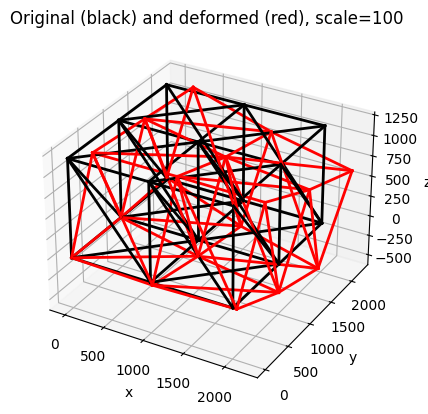

In [94]:
plot_truss_deformation(nodes, element, u_global, scale=100)

In [95]:
results = recover_element_results(element, elements_lmnL, u_global)
df_members = build_element_results_dataframe(element, elements_lmnL, results)

display_compact(df_members)

,ele,i,j,L (mm),N (kN),sigma (MPa),u_1 (mm),u_2 (mm),u_3 (mm),u_4 (mm),u_5 (mm),u_6 (mm),u_1' (mm),u_2' (mm),u_3' (mm),u_4' (mm),u_5' (mm),u_6' (mm),f_1' (kN),f_2' (kN),f_3' (kN),f_4' (kN),f_5' (kN),f_6' (kN)
0,1,1,2,1000.0,64.7,53.9,0.0,0.0,0.0,0.3,-0.1,-0.2,0.0,0.0,0.0,0.3,-0.1,-0.2,-64.7,0.0,0.0,64.7,0.0,0.0
1,2,2,3,1000.0,46.7,38.9,0.3,-0.1,-0.2,0.5,0.0,0.0,0.3,-0.1,-0.2,0.5,0.0,0.0,-46.7,0.0,0.0,46.7,0.0,0.0
2,3,4,5,1000.0,16.1,13.4,-0.1,0.2,-0.1,-0.1,-0.0,-2.0,-0.1,0.2,-0.1,-0.1,-0.0,-2.0,-16.1,0.0,0.0,16.1,0.0,0.0
3,4,5,6,1000.0,28.9,24.1,-0.1,-0.0,-2.0,0.1,-0.0,-3.5,-0.1,-0.0,-2.0,0.1,-0.0,-3.5,-28.9,0.0,0.0,28.9,0.0,0.0
4,5,7,8,1000.0,-0.0,-0.0,-0.3,0.3,0.0,-0.3,0.1,-3.4,-0.3,0.3,0.0,-0.3,0.1,-3.4,0.0,0.0,0.0,0.0,0.0,0.0
5,6,8,9,1000.0,9.4,7.9,-0.3,0.1,-3.4,-0.3,0.0,-5.9,-0.3,0.1,-3.4,-0.3,0.0,-5.9,-9.4,0.0,0.0,9.4,0.0,0.0
6,7,1,4,1000.0,42.2,35.2,0.0,0.0,0.0,-0.1,0.2,-0.1,0.0,0.0,0.0,0.2,0.1,-0.1,-42.2,0.0,0.0,42.2,0.0,0.0
7,8,4,7,1000.0,35.3,29.4,-0.1,0.2,-0.1,-0.3,0.3,0.0,0.2,0.1,-0.1,0.3,0.3,0.0,-35.3,0.0,0.0,35.3,0.0,0.0
8,9,2,5,1000.0,12.4,10.3,0.3,-0.1,-0.2,-0.1,-0.0,-2.0,-0.1,-0.3,-0.2,-0.0,0.1,-2.0,-12.4,0.0,0.0,12.4,0.0,0.0
9,10,5,8,1000.0,29.3,24.4,-0.1,-0.0,-2.0,-0.3,0.1,-3.4,-0.0,0.1,-2.0,0.1,0.3,-3.4,-29.3,0.0,0.0,29.3,0.0,0.0


In [96]:
# Choose one element to sanity-check
e_test = 1

# --- Geometry + properties ---
i, j, E, A = element[e_test]
l, m, n, L = elements_lmnL[e_test]


print(f"Element {e_test}: nodes ({i}, {j})")
print(f"l = {l:.6f}, m = {m:.6f},n = {n:.6f}, L = {L:.3f} mm")

# --- Displacements ---
u_e = extract_element_displacements(u_global, i, j)
print(f"u_e (ele {e_test} global displacements) = {u_e}")

u_local = compute_local_displacements(l,m,n, u_e)
print(f"u_local (ele {e_test} local displacements) = {u_local}")

# --- Forces / stress ---
f_local = compute_local_end_forces(E, A, L, u_local)
print(f"f_local (ele {e_test} local end forces) = {f_local}")

N, sigma = compute_axial_force_and_stress(E, A, L, u_local)
print(f"Axial force  N = {N:.3f} kN")
print(f"Axial stress σ = {sigma:.6f} GPa  ({sigma*1000:.2f} MPa)")

f_global_e = local_to_global_forces(l,m,n, f_local)
print(f"f_global_e (ele {e_test} end forces in global coords) = {f_global_e}")


Element 1: nodes (1, 2)
l = 1.000000, m = 0.000000,n = 0.000000, L = 1000.000 mm
u_e (ele 1 global displacements) = [ 0.     0.     0.     0.27  -0.056 -0.239]
u_local (ele 1 local displacements) = [ 0.     0.     0.     0.27  -0.056 -0.239]
f_local (ele 1 local end forces) = [-64.68   0.     0.    64.68   0.     0.  ]
Axial force  N = 64.680 kN
Axial stress σ = 0.053900 GPa  (53.90 MPa)
f_global_e (ele 1 end forces in global coords) = [-64.68   0.     0.    64.68   0.     0.  ]


In [97]:
print("Support reactions by node:")
for node in sorted(nodes_restrained.keys()):
    Rx = 0.0
    Ry = 0.0
    Rz=0.0

    if "ux" in nodes_restrained[node]:
        dof0 = 3*node - 3
        Rx = float(F_r[list(restrained_dofs).index(dof0)])
    if "uy" in nodes_restrained[node]:
        dof0 = 3*node - 2
        Ry = float(F_r[list(restrained_dofs).index(dof0)])
    if "uz" in nodes_restrained[node]:
        dof0 = 3*node - 1
        Rz = float(F_r[list(restrained_dofs).index(dof0)])

    print(f"Node {node}: Rx = {Rx:.6g} kN, Ry = {Ry:.6g} kN, Rz = {Rz:.6g} kN")

Support reactions by node:
Node 1: Rx = -60 kN, Ry = -37.5 kN, Rz = -54 kN
Node 3: Rx = 0 kN, Ry = 7.5 kN, Rz = 101 kN
Node 7: Rx = 0 kN, Ry = 0 kN, Rz = 83 kN


### YOUR ANSWER FOR Q4.2 IN THIS CELL:

Use as many cells as you need
##Support reactions

Node 1: Rx = -60 kN, Ry = -37.5 kN, Rz = -54 kN\
Node 3: Rx = 0 kN, Ry = 7.5 kN, Rz = 101 kN\
Node 7: Rx = 0 kN, Ry = 0 kN, Rz = 83 kN
## Member axial forces


1.  N = 64.7 kN (T)  
2.  N = 46.7 kN (T)  
3.  N = 16.1 kN (T)  
4.  N = 28.9 kN (T)  
5.  N = 0.0 kN (T)  
6.  N = -9.4 kN (C)  
7.  N = 42.2 kN (T)  
8.  N = 35.3 kN (T)  
9.  N = 12.4 kN (T)  
10. N = 29.3 kN (T)  
11. N = -7.5 kN (C)  
12. N = 9.2 kN (T)  
13. N = -6.6 kN (C)  
14. N = -17.5 kN (C)  
15. N = -22.8 kN (C)  
16. N = -19.1 kN (C)  
17. N = -7.1 kN (C)  
18. N = 10.0 kN (T)  
19. N = -29.8 kN (C)  
20. N = -14.6 kN (C)  
21. N = -30.6 kN (C)  
22. N = -18.8 kN (C)  
23. N = -14.4 kN (C)  
24. N = 0.0 kN (T)  
25. N = -37.7 kN (C)  
26. N = -20.9 kN (C)  
27. N = -39.1 kN (C)  
28. N = -23.8 kN (C)  
29. N = 38.8 kN (T)  
30. N = 27.7 kN (T)  
31. N = 29.5 kN (T)  
32. N = 33.6 kN (T)  
33. N = 54.0 kN (T)  
34. N = 36.4 kN (T)  
35. N = -44.9 kN (C)  
36. N = 27.6 kN (T)  
37. N = -14.4 kN (C)  
38. N = -15.1 kN (C)  
39. N = -40.7 kN (C)  
40. N = -14.9 kN (C)  
41. N = -10.0 kN (C)  
42. N = -47.4 kN (C)  
43. N = -73.0 kN (C)  
44. N = 6.1 kN (T)  
45. N = -25.8 kN (C)  
46. N = 39.9 kN (T)  
47. N = 6.3 kN (T)  
48. N = -36.0 kN (C)  
49. N = -55.1 kN (C)  
50. N = 12.6 kN (T)  
51. N = -20.6 kN (C)  
52. N = 45.4 kN (T)  
53. N = 6.7 kN (T)  

## Maximum nodal displacements
Global x direction= 2.6 mm ( node 16)\
Global y direction= 2.8 mm ( node 12)\
Global z direction= -5.9 mm ( node 12)
##Present summary tables
(see previous cell)
##Plot displaced shape at a reasonable scale
(see previous cell)


---


### Q4.3. Discussion
Discuss the computed **member forces** and **nodal displacements**.

Interpret your results from an engineering perspective by addressing the following questions:

- Are the computed displacements and deformed shape physically reasonable for the structure and loading considered?
- Do the signs and magnitudes of member forces and support reactions make sense?
- Which members carry the largest axial forces, and how does this relate to the expected load paths?
- How do your modeling assumptions (geometry, cross-sections, boundary conditions) influence the results?
- Which assumptions do you expect the results to be most sensitive to, and why?


### YOUR ANSWER FOR Q4.3 IN THIS CELL:

- **Are the computed displacements and deformed shape physically reasonable for the structure and loading considered?**\
The deformed shape is physically reasonable. The top layer nodes displace downward (negative z) under the applied vertical loads, with some accompanying lateral drift in x and y due to the non-symmetric horizontal loading (net Fx = +60 kN, net Fy = +30 kN). From the results table, the largest global displacement magnitude occurs with Ux = 2.6 mm, Uy = 2.8 mm, Uz = -5.9 mm, which is also consistent direction and magnitudes. The unsupported bottom corner node is showing displacement, which is also reasonable.
- **Do the signs and magnitudes of member forces and support reactions make sense?**\
The signs and magnitudes of member forces are also reasonable for a space truss: several members are in compression (negative N) forming the primary load-carrying struts, while others are in tension (positive N) acting as ties to stabilize the load path.
- **Which members carry the largest axial forces, and how does this relate to the expected load paths?**\
The largest tension force is in element 1 with N = 64.7 kN (tension), and the largest compression force is in element 43 with N = -73.0 kN (compression). One node of element 1 is the only support resisting translation in x direction. So, naturally the horizontal element (element 1) will carry the maximum load in that direction. The members carrying the largest axial forces are those that connect the loaded region to the supports through direct diagonal/vertical load paths. These members attract higher force because they provide the shortest/direct route for transferring vertical and horizontal components of the applied loads to the supports, applicable for element 43 which is connected to another support.
- **How do your modeling assumptions (geometry, cross-sections, boundary conditions) influence the results?**\
The geometry and boundary conditions influence the results a lot. As these are directly connected to the structure being stable or not. If it is not, then we would get matrix which cannot be inversed and consequently would not get a solution. The boundary conditions also determine the path the loads will travel and determine member forces as such. Cross sections are important to see if the members are overstressed or are at risk of failure at any point.
- **Which assumptions do you expect the results to be most sensitive to, and why?**\
I think that the joint connections and the supports are the most sensitive points for the results. If the support conditions change, the member forces would change drastically. If the joint connection changes, the joint would have to redistribute the forces in a new way, causing further and further changes to sequential connecting members

---

## Reflection (Required)

In 3–6 sentences:

- What part felt easiest? Describe in speciics
- What part felt hardest? Describe in speciics
- One bug you encountered and how you fixed it.
- One thing you still don’t understand.
- If you used collaboration or AI tools, briefly describe how.


### YOUR RESPONSE HERE

- **What part felt easiest? Describe in speciics**\
Recreating the 2D truss to 3D.The past information could be copied and only needed mild changes
- **What part felt hardest? Describe in speciics**\
In the 3D code, I unintentionally changed the directory name to a function name and it was very difficult to fix. Took a long time to understand what happened and longer to fix
- **One bug you encountered and how you fixed it.**\
In a matrix that used lm, I had defined ml and not lm and it of course did not recognize what lm is but I was blind to it and later realized after going through the complete error message.
- **One thing you still don’t understand.**\
I am not too sure of the new way of plotting as I did not have to work on it using plotly.
- **If you used collaboration or AI tools, briefly describe how.**\
I used AI to fix a few bugs regarding the same function and directory name.